## **CNN CON DATASET MNIST**

#### **- Cargando el conjunto de datos**

In [2]:
import tensorflow as tf
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape)
print("Para el entrenamiento tenemos 60000 imagenes con resolution 28x28")
print(y_train.shape)
print(x_test.shape)
print("Para el test tenemos 10000 imagenes con resolution 28x28")
print(y_test.shape)



(60000, 28, 28)
Para el entrenamiento tenemos 60000 imagenes con resolution 28x28
(60000,)
(10000, 28, 28)
Para el test tenemos 10000 imagenes con resolution 28x28
(10000,)


#### **- Acondicionando el conjunto de datos**

In [3]:
# Preprocesado obligatorio cuando trabajo con redes neuronales
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# PREPROCESAMEINTO DE DATOS (Normalisacion de imagenes)
x_train, x_te = x_train / 255.0, x_test / 255.0 # Cambio al rango [0,1]

# etiquetas estan en 0-9, dejamos las etiquetas en formato decimal, no convertimos a one hot encoding
#y_train = to_categorical(y_train, num_classes=10) # One-hot encoding para minimizar error
#y_te = to_categorical(y_test, num_classes=10)
print(y_train[0])

5


In [4]:
# PARTICIÓN DE LOS DATOS (extrayendo datos del train para poder validarlo luego)
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42) # 3 subconjuntos es de vital importancia

In [8]:
from tensorflow.keras.backend import expand_dims

# Expandir dimensiones para ajustar el input a una "CNN" a RGB porque actualmente estamos con imagenes
# con escala de grises entonces debemos expandir las dimensiones para simular 3 capas(RGB)
print("Dimension actual: ")
print( x_tr.shape)
x_tr = expand_dims(x_tr, axis=3)
x_val = expand_dims(x_val, axis=3)
x_te = expand_dims(x_te, axis=3)

print("Agregando una nueva dimension: ")
print(x_tr.shape)

Dimension actual: 
(54000, 28, 28, 1)
Agregando una nueva dimension: 
(54000, 28, 28, 1, 1)


In [6]:
# tenemos 54000 imagenes de 28*28 de tamano y dimension extra porque asi le gusta CNN en RGB

#### **- Creando la topología de Red Neuronal (CNN) y entrenándola**

In [18]:
# Construccion de una red CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

# API secuencial
convnet = Sequential()

# BASE MODEL
convnet.add(layers.Conv2D(32, (3,3), input_shape=(28,28,1), activation='relu'))
convnet.add(layers.MaxPooling2D((2,2))) # reduciendo dimension

convnet.add(layers.Conv2D(64, (3,3), activation='relu'))
convnet.add(layers.MaxPooling2D((2,2)))

convnet.add(layers.Conv2D(64, (3,3), activation='relu'))

# TOP MODEL
convnet.add(layers.Flatten())
convnet.add(layers.Dense(64, activation='relu'))
convnet.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
convnet.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
convnet.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               # loss='categorical_crossentropy', # Si las etiquetas están en one-hot encoded
               metrics=['accuracy'])

In [21]:
# se especifico un epochs de 5 por la experienza que se trata de un modelo pequeno.
H = convnet.fit(x_tr, y_tr, epochs=5, batch_size=128, validation_data=(x_val, y_val))

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9217 - loss: 0.2589 - val_accuracy: 0.9692 - val_loss: 0.1036
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9804 - loss: 0.0644 - val_accuracy: 0.9855 - val_loss: 0.0544
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9866 - loss: 0.0424 - val_accuracy: 0.9875 - val_loss: 0.0446
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9893 - loss: 0.0346 - val_accuracy: 0.9875 - val_loss: 0.0443
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9917 - loss: 0.0264 - val_accuracy: 0.9907 - val_loss: 0.0348


#### **- Observando el proceso de entrenamiento para tomar decisiones**

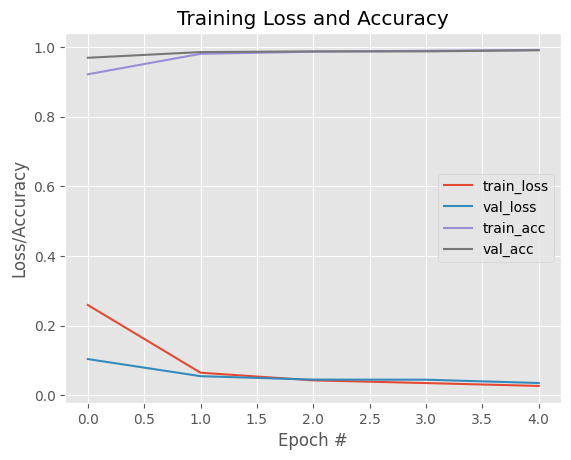

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Gráficas de evaluación durante el entrenamiento
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 5), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 5), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 5), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 5), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

Resumen:
La accuracy se acerca al 100% entonces no nesecita que realicemos un custom del modelo

#### **- Sacando las predicciones en el subset de test y evaluando la performance del modelo**

In [26]:
from sklearn.metrics import classification_report

# Evaluando el modelo de predicción con las imágenes de test
predictions = convnet.predict(x_te, batch_size=128)
# pasando las predicciones a un formato decimal argmax
print(classification_report(y_test, predictions.argmax(axis=1)))

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [35]:
print("Prediction")
predictions[0]

Prediction


array([3.1064740e-08, 2.6054178e-07, 3.5226199e-07, 1.2536248e-05,
       2.8805085e-08, 1.5902695e-07, 1.3174483e-11, 9.9998367e-01,
       4.5945157e-07, 2.5367026e-06], dtype=float32)

Resumen: Podemos ver que la prediction[0] se trata al 99.9% del numero 7.

In [36]:
y_test[0] # siguen en formato decimal entonces no nesecita usar argmax para decodificar el ohe

np.uint8(7)

In [37]:
print("precision 99.99%")

precision 99.99%
